In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
original_dir = os.getcwd()

root_path = os.path.dirname(os.path.dirname(original_dir))
os.chdir(root_path)

from utils.mlflow_utils import start_run, end_run
from utils.analysis_utils import (
    log_metrics,
    log_table,
    log_figure,
    log_text
)
from utils.plotting import setup_plotting

In [2]:
setup_plotting()

ARTIFACT_DIR = "dataset_overview"

start_run("2.1 Dataset Overview")

2026/07/24 16:51:53 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/24 16:51:53 INFO mlflow.store.db.utils: Updating database tables
2026/07/24 16:51:54 INFO mlflow.tracking.fluent: Experiment with name 'Sales_Forecasting_FreshRetailNet-50K Dataset' does not exist. Creating a new experiment.


In [3]:
df = pd.read_csv("E:\\FreshRetailNet\\csv_data\\train.csv")

In [4]:
metrics = {
    "n_rows": len(df),
    "n_columns": df.shape[1],
    "memory_mb": round(df.memory_usage(deep=True).sum() / (1024**2), 2),

    "n_days": df["dt"].nunique(),

    "n_city": df["city_id"].nunique(),
    "n_store": df["store_id"].nunique(),
    "n_management_group": df["management_group_id"].nunique(),

    "n_first_category": df["first_category_id"].nunique(),
    "n_second_category": df["second_category_id"].nunique(),
    "n_third_category": df["third_category_id"].nunique(),

    "n_product": df["product_id"].nunique(),
}

summary_df = (
    pd.Series(metrics, name="Value")
      .rename_axis("Metric")
      .reset_index()
)

summary_df

,Metric,Value
0,n_rows,47340.00
1,n_columns,19.00
2,memory_mb,22.63
3,n_days,90.00
4,n_city,6.00
5,n_store,10.00
6,n_management_group,7.00
7,n_first_category,24.00
8,n_second_category,50.00
9,n_third_category,128.00


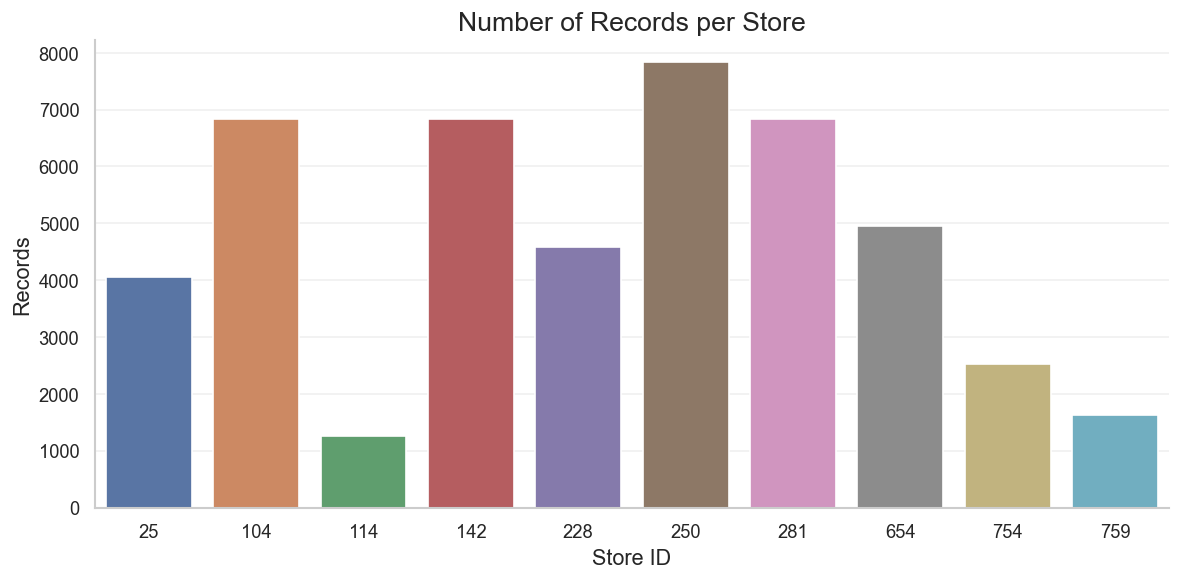

In [5]:
store_summary = (
    df.groupby("store_id")
      .size()
      .reset_index(name="records")
)

fig_records, ax = plt.subplots()

sns.barplot(
    data=store_summary,
    x="store_id",
    y="records",
    ax=ax
)

ax.set_title("Number of Records per Store")
ax.set_xlabel("Store ID")
ax.set_ylabel("Records")

plt.show()

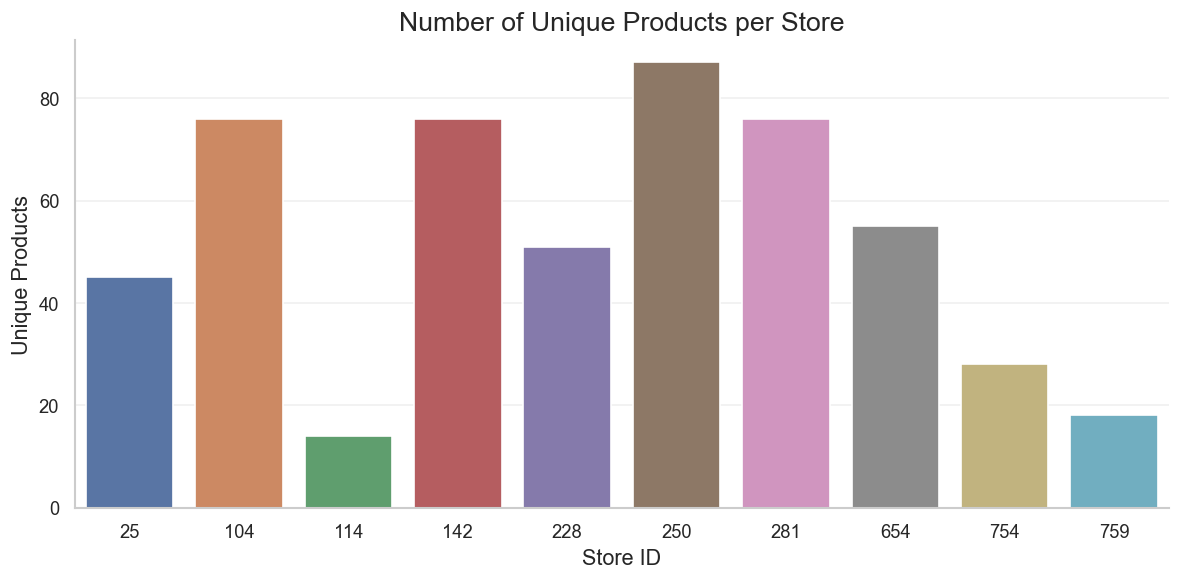

In [6]:
product_summary = (
    df.groupby("store_id")["product_id"]
      .nunique()
      .reset_index(name="unique_products")
)

fig_products, ax = plt.subplots()

sns.barplot(
    data=product_summary,
    x="store_id",
    y="unique_products",
    ax=ax
)

ax.set_title("Number of Unique Products per Store")
ax.set_xlabel("Store ID")
ax.set_ylabel("Unique Products")

plt.show()

In [7]:
interpretation = """
# Interpretation

- The selected 10 stores are not uniformly represented in the dataset.
- Store **250** contains the largest number of records and the highest number of unique products among the selected stores.
- Stores **104**, **142**, and **281** have similar dataset sizes and product diversity.
- Stores **114** and **759** contain considerably fewer records and products than the other stores.
- The number of records per store is strongly associated with the number of unique products, suggesting that larger datasets generally correspond to stores with a broader product assortment.
- The selected stores exhibit varying data volumes, which provides a representative subset for exploratory analysis and development.
"""

print(interpretation)


# Interpretation

- The selected 10 stores are not uniformly represented in the dataset.
- Store **250** contains the largest number of records and the highest number of unique products among the selected stores.
- Stores **104**, **142**, and **281** have similar dataset sizes and product diversity.
- Stores **114** and **759** contain considerably fewer records and products than the other stores.
- The number of records per store is strongly associated with the number of unique products, suggesting that larger datasets generally correspond to stores with a broader product assortment.
- The selected stores exhibit varying data volumes, which provides a representative subset for exploratory analysis and development.



In [8]:
decision = """
# Decision

- No action is required at this stage.
"""

print(decision)


# Decision

- No action is required at this stage.



In [9]:
log_metrics(metrics)

log_table(
    summary_df,
    f"{ARTIFACT_DIR}/summary_table.json"
)

log_figure(
    fig_records,
    f"{ARTIFACT_DIR}/records_per_store.png"
)

log_figure(
    fig_products,
    f"{ARTIFACT_DIR}/products_per_store.png"
)

log_text(
    interpretation,
    f"{ARTIFACT_DIR}/interpretation.md"
)

log_text(
    decision,
    f"{ARTIFACT_DIR}/decision.md"
)

In [10]:
end_run()